<a href="https://colab.research.google.com/github/Alaaaziz97/MyProjects/blob/main/KafaatProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read & Clean the dataset, and Understand its structure.
df = pd.read_csv('https://raw.githubusercontent.com/Alaaaziz97/MyProjects/refs/heads/main/Kafaat.csv')

print('The dataset has', df.duplicated().sum(), 'duplicate records.\n')
print('Missing values per column:\n', df.isnull().sum(),'\n')

print('Understand the dataset structure:')
df.info()

The dataset has 0 duplicate records.

Missing values per column:
 Organization Name              0
Type                           0
Full-Time Employees            0
Part-Time Employees            0
Volunteers                     0
City                           0
Region                         0
Planned Projects               0
Executed Projects              0
Rating (out of 100)            0
Supervising Ministry           0
Target Group                   0
Main Activity Area             0
Founded Year                   0
Accreditation Status           0
Number of Beneficiaries        0
Workshops Conducted            0
Training Sessions Conducted    0
Volunteer Hours Contributed    0
Staff Retention Rate (%)       0
Digital Presence               0
dtype: int64 

Understand the dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                 

In [ ]:
# ربط المدن بالمناطق الصحيحة
city_to_region = {
    'Abha': 'Southern',
    'Hail': 'Northern',
    'Jeddah': 'Western',
    'Makkah': 'Western',
    'Dammam': 'Eastern',
    'Medina': 'Western',
    'Tabuk': 'Northern',
    'Riyadh': 'Central',
    'Najran': 'Southern',
    'Taif': 'Western'
}

# إنشاء عمود جديد بالمناطق الصحيحة
df['Correct Region'] = df['City'].map(city_to_region)
df['Region'] = df['Correct Region']

In [ ]:
df.head()

,Organization Name,Type,Full-Time Employees,Part-Time Employees,Volunteers,City,Region,Planned Projects,Executed Projects,Rating (out of 100),...,Main Activity Area,Founded Year,Accreditation Status,Number of Beneficiaries,Workshops Conducted,Training Sessions Conducted,Volunteer Hours Contributed,Staff Retention Rate (%),Digital Presence,Correct Region
0,Foundation Harmony Network,Technology,19,27,248,Abha,Southern,9,18,63,...,Community Engagement,2020,Accredited,188,54,79,7236,96,Yes,Southern
1,Foundation Progress Mission,Youth,36,3,116,Hail,Northern,9,0,100,...,Awareness,2001,Pending,2860,20,1,1737,96,No,Northern
2,Association Innovation Mission,Youth,36,4,34,Jeddah,Western,19,11,89,...,Training,2003,Accredited,173,75,91,9769,77,Yes,Western
3,Center Development Group,Charitable,33,14,146,Abha,Southern,15,2,70,...,Research,2010,Pending,8775,69,55,9340,92,No,Southern
4,Foundation Unity Network,Cultural,9,28,104,Makkah,Western,5,3,66,...,Research,2002,Unaccredited,7466,87,57,2239,84,No,Western


In [ ]:
df['Main Activity Area'].unique()

array(['Community Engagement', 'Awareness', 'Training', 'Research',
       'Capacity Building', 'Relief', 'Advocacy'], dtype=object)

NameError: name 'inner_labels' is not defined

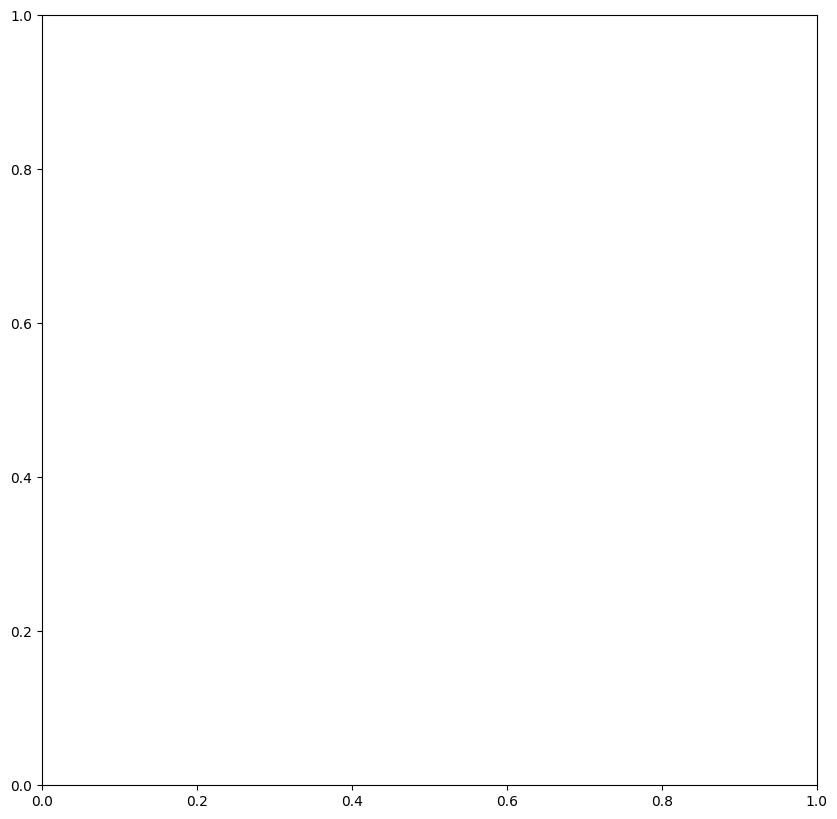

In [ ]:
# إعادة الرسم مع النسب داخل الحلقة الداخلية (الأنواع) وليجند للمناطق فقط

fig, ax = plt.subplots(figsize=(10, 10))

# الداخلية: أنواع المنظمات مع النسب
inner_labels_with_pct = [f"{label}\n{size / sum(inner_sizes) * 100:.1f}%" for label, size in zip(inner_labels, inner_sizes)]
ax.pie(
    inner_sizes,
    radius=0.9,
    labels=inner_labels_with_pct,
    colors=inner_colors,
    labeldistance=0.7,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# الخارجية: المناطق بدون تسميات (نعتمد على الليجند)
ax.pie(
    outer_sizes,
    radius=1.2,
    labels=None,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# ليجند للمناطق فقط
region_legend = [Patch(facecolor=color, label=region) for region, color in region_colors.items()]
ax.legend(handles=region_legend, title='Region', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

ax.set(aspect="equal")
plt.title("Distribution of Regions within Organization Types (with Percentages)")
plt.tight_layout()
plt.show()


<ipython-input-10-0af33dc957aa>:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, full_time[i]/2, f"{full_time[i]:.1f}%", ha='center', va='center', color='white')
<ipython-input-10-0af33dc957aa>:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, full_time[i] + part_time[i]/2, f"{part_time[i]:.1f}%", ha='center', va='center', color='white')


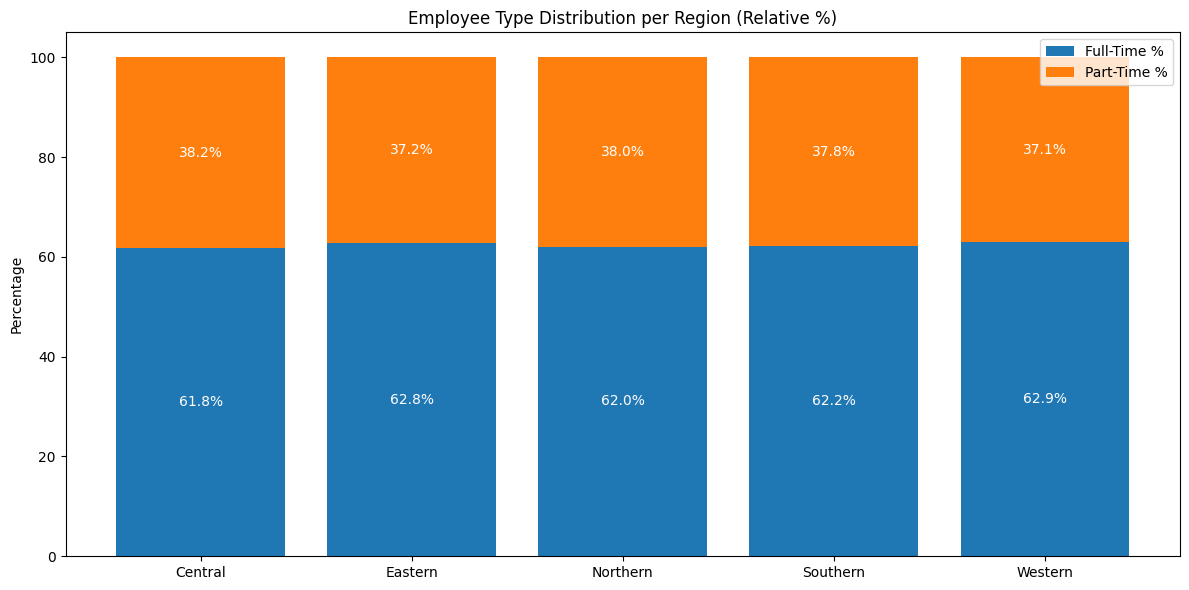

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv('https://raw.githubusercontent.com/Alaaaziz97/MyProjects/refs/heads/main/Kafaat.csv')

# تجميع
grouped = df.groupby('Region')[['Full-Time Employees', 'Part-Time Employees']].sum()

# حساب النسب المئوية
grouped['Total'] = grouped.sum(axis=1)
grouped['Full-Time %'] = grouped['Full-Time Employees'] / grouped['Total'] * 100
grouped['Part-Time %'] = grouped['Part-Time Employees'] / grouped['Total'] * 100

# رسم Stacked Bar Chart
regions = grouped.index
full_time = grouped['Full-Time %']
part_time = grouped['Part-Time %']

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(regions, full_time, label='Full-Time %')
ax.bar(regions, part_time, bottom=full_time, label='Part-Time %')

# إضافة النسب على الأعمدة
for i, region in enumerate(regions):
    ax.text(i, full_time[i]/2, f"{full_time[i]:.1f}%", ha='center', va='center', color='white')
    ax.text(i, full_time[i] + part_time[i]/2, f"{part_time[i]:.1f}%", ha='center', va='center', color='white')

ax.set_ylabel("Percentage")
ax.set_title("Employee Type Distribution per Region (Relative %)")
ax.legend()
plt.tight_layout()
plt.show()


<ipython-input-11-a9a7d76f3be7>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(full_time[i]/2, i, f"{full_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)
<ipython-input-11-a9a7d76f3be7>:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(full_time[i] + part_time[i]/2, i, f"{part_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)


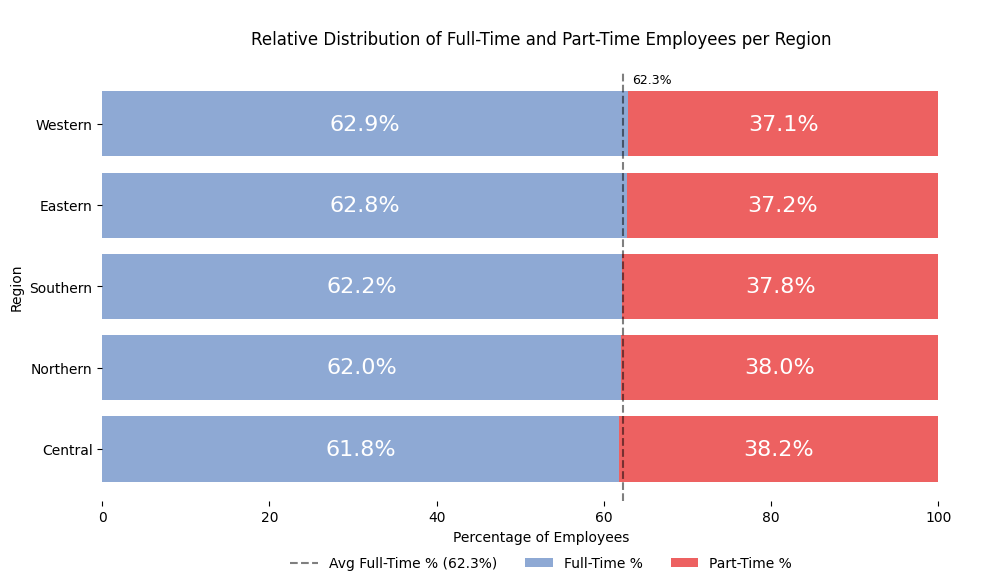

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv('https://raw.githubusercontent.com/Alaaaziz97/MyProjects/refs/heads/main/Kafaat.csv')

# تجميع حسب المنطقة
grouped = df.groupby('Region')[['Full-Time Employees', 'Part-Time Employees']].sum()

# حساب النسب
grouped['Total'] = grouped['Full-Time Employees'] + grouped['Part-Time Employees']
grouped['Full-Time %'] = grouped['Full-Time Employees'] / grouped['Total'] * 100
grouped['Part-Time %'] = grouped['Part-Time Employees'] / grouped['Total'] * 100

# ترتيب حسب نسبة الدوام الكامل (اختياري)
grouped = grouped.sort_values('Full-Time %')

# حساب المتوسط
average_full_time_pct = grouped['Full-Time %'].mean()

# الرسم
regions = grouped.index.tolist()
full_time = grouped['Full-Time %']
part_time = grouped['Part-Time %']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(regions, full_time, label='Full-Time %', color='#8ea9d4')
ax.barh(regions, part_time, left=full_time, label='Part-Time %', color='#ed6161')

# إضافة النسب على الأعمدة
for i, region in enumerate(regions):
    ax.text(full_time[i]/2, i, f"{full_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)
    ax.text(full_time[i] + part_time[i]/2, i, f"{part_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)

# ✅ إضافة الخط العمودي للمتوسط
ax.axvline(average_full_time_pct, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Avg Full-Time % ({average_full_time_pct:.1f}%)')
ax.text(average_full_time_pct + 1, len(regions) - 0.5, f'{average_full_time_pct:.1f}%', color='black', fontsize=9)

# تنسيقات الشكل
ax.set_xlabel("Percentage of Employees")
ax.set_ylabel("Region")
ax.set_title("\nRelative Distribution of Full-Time and Part-Time Employees per Region", pad=20)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
df.describe(include='object')

,Organization Name,Type,City,Region,Supervising Ministry,Target Group,Main Activity Area,Accreditation Status,Digital Presence
count,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,480,9,10,5,8,9,7,3,2
top,Society Development Initiative,Charitable,Tabuk,Southern,Ministry of Municipal and Rural Affairs,Students,Advocacy,Pending,No
freq,21,597,525,1013,658,567,734,1702,2511


In [ ]:
df['Type'].unique()

array(['Technology', 'Youth', 'Charitable', 'Cultural', 'Health',
       'Development', 'Educational', 'Social Services', 'Environmental'],
      dtype=object)

<ipython-input-14-631cbd7c0584>:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, vert=False, patch_artist=True, labels=regions_order)


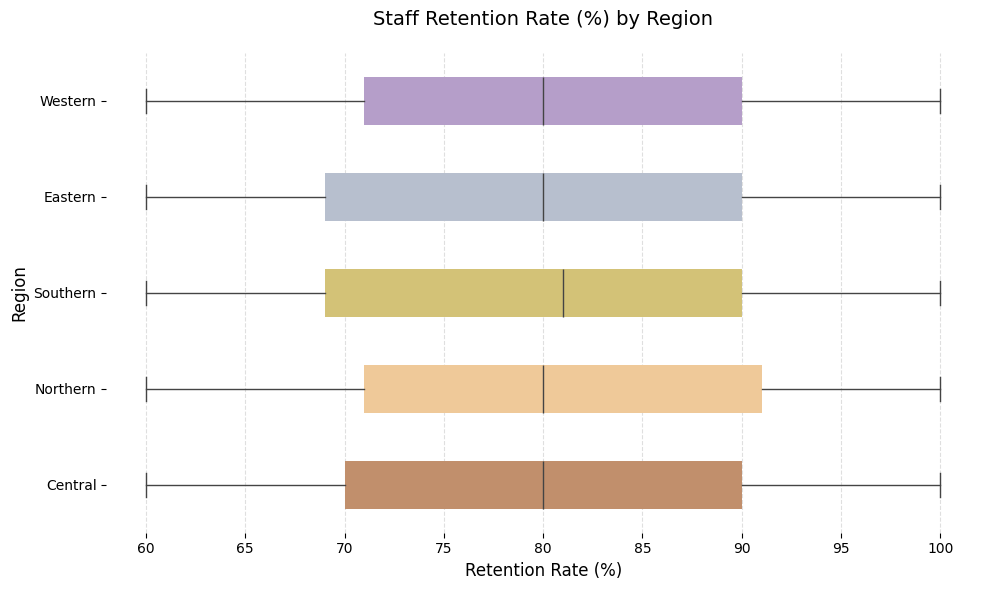

In [ ]:
import matplotlib.pyplot as plt

# الألوان حسب المنطقة (من الصور المرفقة)
region_colors = {
    'Central': '#c18f6c',    # النجدية
    'Eastern': '#b7bfce',    # الشرقية
    'Northern': '#efc999',   # الشمالية
    'Southern': '#d3c277',   # الجنوبية (أبها)
    'Western': '#b59ec9'     # الحجازية
}

# ترتيب المناطق المرغوب عرضها
regions_order = ['Central', 'Northern', 'Southern', 'Eastern', 'Western']

# إعداد البيانات لكل منطقة
data = [df[df['Region'] == region]['Staff Retention Rate (%)'] for region in regions_order]

# إعداد الشكل
fig, ax = plt.subplots(figsize=(10, 6))

# رسم boxplot
box = ax.boxplot(data, vert=False, patch_artist=True, labels=regions_order)

# تلوين كل صندوق حسب المنطقة
for patch, region in zip(box['boxes'], regions_order):
    patch.set_facecolor(region_colors[region])
    patch.set_edgecolor('none')  # ← هذا يحذف الحد الأسود


# تنسيق الخطوط (whiskers, caps, medians)
for element in ['whiskers', 'caps', 'medians']:
    for line in box[element]:
        line.set_color('#444444')  # رمادي أنيق


# تنسيقات العنوان والمحاور
ax.set_title('Staff Retention Rate (%) by Region', fontsize=14, pad=20)
ax.set_xlabel('Retention Rate (%)', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# إزالة الإطار الخارجي
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


<ipython-input-15-f8d733610e4b>:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.barh(region, full_time[i], color=full_color, label='Full-Time %' if i == 0 else "", edgecolor='none')
<ipython-input-15-f8d733610e4b>:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.barh(region, part_time[i], left=full_time[i], color=part_color, label='Part-Time %' if i == 0 else "", edgecolor='none')
<ipython-input-15-f8d733610e4b>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

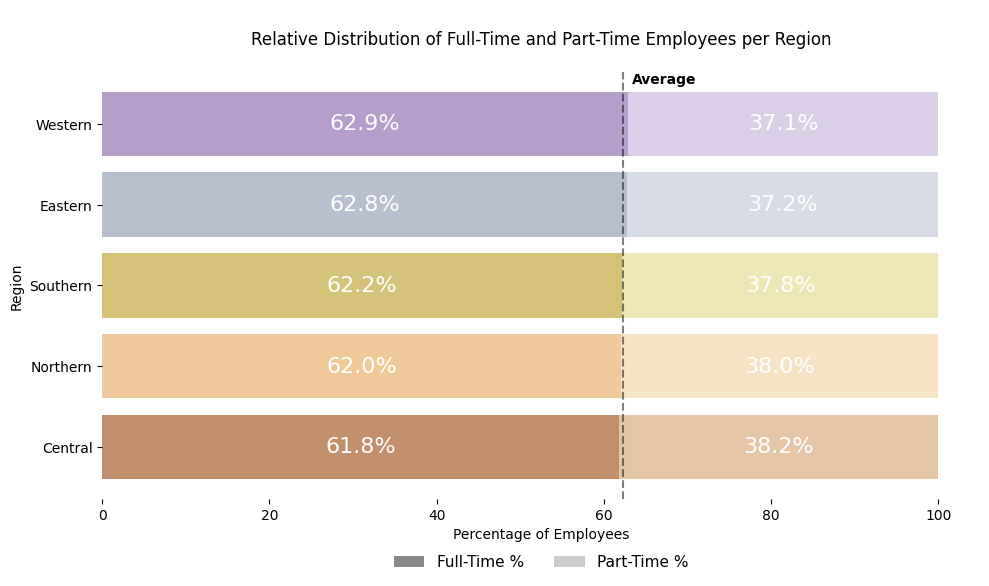

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv('https://raw.githubusercontent.com/Alaaaziz97/MyProjects/refs/heads/main/Kafaat.csv')

# تجميع حسب المنطقة
grouped = df.groupby('Region')[['Full-Time Employees', 'Part-Time Employees']].sum()

# حساب النسب
grouped['Total'] = grouped['Full-Time Employees'] + grouped['Part-Time Employees']
grouped['Full-Time %'] = grouped['Full-Time Employees'] / grouped['Total'] * 100
grouped['Part-Time %'] = grouped['Part-Time Employees'] / grouped['Total'] * 100

# ترتيب حسب نسبة الدوام الكامل (اختياري)
grouped = grouped.sort_values('Full-Time %')

# حساب المتوسط
average_full_time_pct = grouped['Full-Time %'].mean()

# إعداد بيانات الرسم
regions = grouped.index.tolist()
full_time = grouped['Full-Time %']
part_time = grouped['Part-Time %']

# ألوان المناطق (أساسية + أفتح)
region_colors = {
    'Central':      ('#c18f6c', '#e4c5a8'),  # نجدية
    'Eastern':      ('#b7bfce', '#d7dce6'),  # شرقية
    'Northern':     ('#efc999', '#f7e4c7'),  # شمالية
    'Southern':     ('#d3c277', '#ede7b8'),  # جنوبية
    'Western':      ('#b59ec9', '#dacfe7')   # حجازية
}

# الرسم
fig, ax = plt.subplots(figsize=(10, 6))

for i, region in enumerate(regions):
    full_color, part_color = region_colors[region]
    ax.barh(region, full_time[i], color=full_color, label='Full-Time %' if i == 0 else "", edgecolor='none')
    ax.barh(region, part_time[i], left=full_time[i], color=part_color, label='Part-Time %' if i == 0 else "", edgecolor='none')

    # النصوص
    ax.text(full_time[i]/2, i, f"{full_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)
    ax.text(full_time[i] + part_time[i]/2, i, f"{part_time[i]:.1f}%", va='center', ha='center', color='white', fontsize=16)

# خط المتوسط
ax.axvline(average_full_time_pct, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Avg Full-Time % ({average_full_time_pct:.1f}%)')
ax.text(average_full_time_pct + 1, len(regions) - 0.5, 'Average', color='black', fontsize=10, fontweight='bold')

# تنسيقات الشكل
ax.set_xlabel("Percentage of Employees")
ax.set_ylabel("Region")
ax.set_title("\nRelative Distribution of Full-Time and Part-Time Employees per Region", pad=20)
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

# إزالة الإطار
for spine in ax.spines.values():
    spine.set_visible(False)


from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor='#888888', label='Full-Time %'),   # رصاصي غامق
    Patch(facecolor='#cccccc', label='Part-Time %')    # رصاصي فاتح
]
ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False,
    fontsize=11
)
plt.tight_layout()
plt.show()

In [ ]:
# Table: Top 5 organizations.
top_orgs = df['Organization Name'].value_counts().head(5)
print(top_orgs)

Organization Name
Society Development Initiative         21
Foundation Innovation for Youth        20
Association Harmony for Development    20
Initiative Prosperity Group            20
Society Care for Change                19
Name: count, dtype: int64


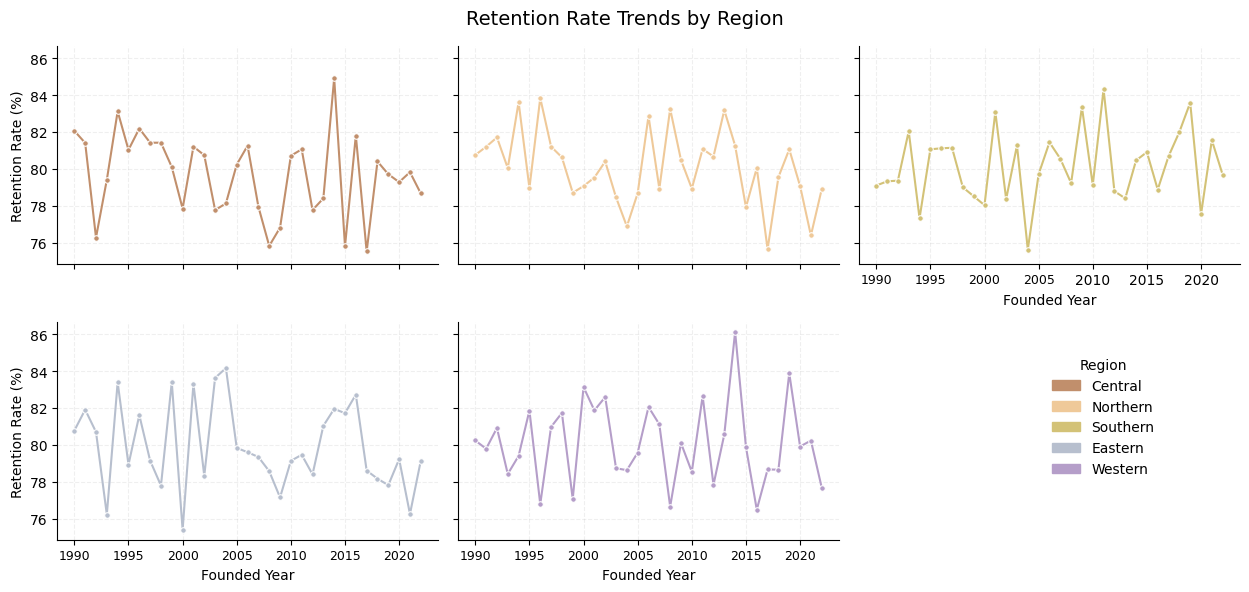

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# تحميل البيانات
df = pd.read_csv('https://raw.githubusercontent.com/Alaaaziz97/MyProjects/refs/heads/main/Kafaat.csv')

# إعداد البيانات
avg_by_region_year = df.groupby(['Region', 'Founded Year'])['Staff Retention Rate (%)'].mean().reset_index()

# ترتيب وألوان المناطق
region_order = ['Central', 'Northern', 'Southern', 'Eastern', 'Western']
region_colors = {
    'Central': '#c18f6c',
    'Eastern': '#b7bfce',
    'Northern': '#efc999',
    'Southern': '#d3c277',
    'Western': '#b59ec9'
}
avg_by_region_year['Color'] = avg_by_region_year['Region'].map(region_colors)

# إنشاء الشبكة
g = sns.FacetGrid(avg_by_region_year, col='Region', col_wrap=3, height=3, aspect=1.4,
                  col_order=region_order, sharex=True, sharey=True, despine=True)

# رسم الخطوط بالنقاط
g.map_dataframe(sns.lineplot, x='Founded Year', y='Staff Retention Rate (%)',
                marker='o', markersize=4, linewidth=1.5)

# تخصيص كل محور
for ax, region in zip(g.axes.flatten(), region_order):
    ax.lines[0].set_color(region_colors[region])
    ax.set_title("")  # حذف العناوين العلوية
    ax.grid(True, axis='both', linestyle='--', alpha=0.2)
    ax.set_xticks([1990, 2000, 2010, 2020])
    ax.set_xticklabels([1990, 2000, 2010, 2020], fontsize=9)

# فقط الصف العلوي نخفي منه محور السنوات
# نحصل على السنوات المرتبة من البيانات
selected_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020]

for i, ax in enumerate(g.axes.flatten()):
    ax.set_xticks(selected_years)
    if i < 3:  # الصف العلوي
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:  # الصف السفلي
        ax.set_xticklabels(selected_years, fontsize=9, rotation=0)


# ليجند يدوي داخل المساحة الفارغة
legend_patches = [Patch(color=region_colors[r], label=r) for r in region_order]
g.fig.legend(handles=legend_patches, title='Region',
             loc='center right', bbox_to_anchor=(0.93, 0.3), frameon=False, fontsize=10)

# تنسيقات العنوان العام والمحاور
g.set_axis_labels("Founded Year", "Retention Rate (%)")
g.fig.subplots_adjust(top=0.88, bottom=0.1, right=0.85)
g.fig.suptitle('Retention Rate Trends by Region', fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
df['Founded Year'].unique()

array([2020, 2001, 2003, 2010, 2002, 1993, 2018, 2022, 1992, 2008, 2017,
       2011, 2015, 1990, 2000, 1999, 2009, 2004, 2021, 1996, 2012, 1991,
       1994, 2016, 1997, 2014, 2013, 2007, 2006, 1998, 2005, 1995, 2019])

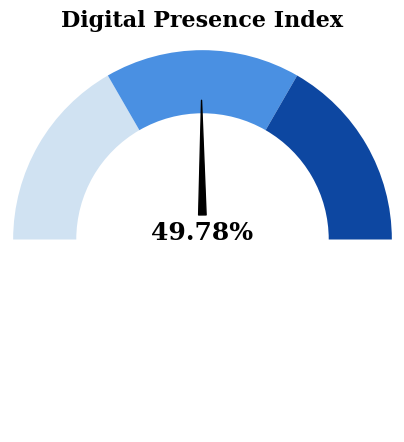

In [ ]:
# Digital Present Index (1/3)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family'] = 'serif'


numDigital = df['Digital Presence'].str.strip().str.lower().eq('yes').sum()
rateDigital = numDigital / len(df)
theta = rateDigital * np.pi

#colors = ['#c8e6c9', '#66bb6a', '#2e7d32']
colors = ['#d0e2f2', '#4a90e2', '#0d47a1']
values = ['0%', '25%', '75%', '100%']

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection='polar')
ax.set_theta_zero_location('W')
ax.set_theta_direction(-1)
#القطع
ax.bar(x=np.arange(0, np.pi, np.pi/3), width= np.pi / 3, height=1, bottom=2, color=colors, align='edge')
#المؤشر
plt.annotate(f"{rateDigital*100:.2f}%", xytext=(0,0), xy=(theta,2.25),
             arrowprops=dict(arrowstyle='wedge', color='black'),
             fontsize=18, fontweight='bold', ha='center')
#العنوان
plt.title("Digital Presence Index", y=1, fontsize=16, fontweight='bold', pad=15)

ax.set_axis_off()

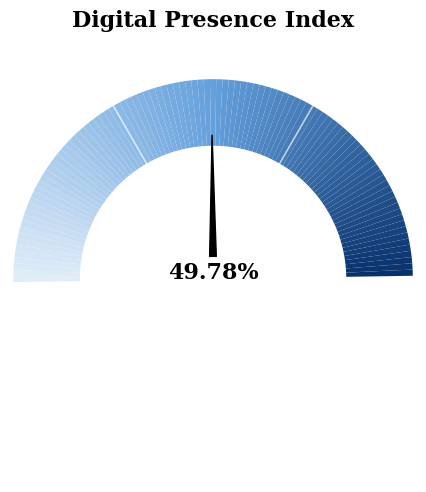

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge
from matplotlib.colors import LinearSegmentedColormap

# قيمة الحضور الرقمي
rateDigital = 0.4978  # ← غيّرها حسب حاجتك
theta = rateDigital * np.pi

# إعداد التدرج الأزرق
colors = ['#e0ecf8', '#64a0dc', '#08306b']  # تدرج ناعم
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors, N=256)

# الشكل
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('W')
ax.set_theta_direction(-1)
ax.set_axis_off()

# تقسيم النصف دائرة إلى تدرجات كثيرة
n_segments = 100
for i in range(n_segments):
    start_angle = i * np.pi / n_segments
    ax.bar(
        x=start_angle,
        height=1,
        width=np.pi / n_segments,
        bottom=2,
        color=custom_cmap(i / n_segments),
        edgecolor='none'
    )

# رسم المؤشر
ax.annotate(f"{rateDigital * 100:.2f}%", xy=(theta, 2.2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='wedge', color='black'),
            fontsize=16, fontweight='bold', ha='center')

# خطوط بيضاء تقسم النصف إلى ثلاث أجزاء
for angle in [np.pi / 3, 2 * np.pi / 3]:
    ax.plot([angle, angle], [2, 3], color='white', linewidth=1, alpha=0.7)

# العنوان
plt.title("Digital Presence Index", y=1.1, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# تحميل البيانات

df['Digital Presence'] = df['Digital Presence'].str.strip().str.lower()

# ترتيب الأعمدة كما بالصورة
region_order = ['Western', 'Eastern', 'Southern', 'Northern', 'Central']
df['Region'] = pd.Categorical(df['Region'], categories=region_order, ordered=True)

# ألوان المناطق (RGB)
base_colors = {
    'Central': (193, 143, 108),
    'Eastern': (183, 191, 206),
    'Northern': (239, 201, 153),
    'Southern': (211, 194, 119),
    'Western': (181, 158, 201)
}

# توليد الألوان حسب الحضور الرقمي
def rgba(rgb, alpha):
    return f'rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha})'

# إعداد البيانات
bar_data = df.groupby(['Region', 'Digital Presence']).size().reset_index(name='Count')
bar_data['Percentage'] = bar_data.groupby('Region')['Count'].transform(lambda x: x / x.sum())
bar_data['Label'] = bar_data.apply(lambda row: f"{row['Count']} ({row['Percentage']*100:.1f}%)", axis=1)
bar_data['Digital Presence'] = pd.Categorical(bar_data['Digital Presence'], categories=['yes', 'no'], ordered=True)
bar_data = bar_data.sort_values(['Region', 'Digital Presence'])

# الرسم
fig = go.Figure()
for presence in ['yes', 'no']:
    subset = bar_data[bar_data['Digital Presence'] == presence]
    colors = [
        rgba(base_colors[region], 1 if presence == 'yes' else 0.4)
        for region in subset['Region']
    ]
    fig.add_trace(go.Bar(
        x=subset['Region'],
        y=subset['Count'],
        name=presence,
        text=subset['Label'],
        textposition='inside',
        marker_color=colors,
        width=0.5,
        showlegend=False
    ))

# ليجند يدوي بلون رصاصي
fig.add_trace(go.Bar(x=[None], y=[None], name='yes', marker_color='rgba(50,50,50,1)'))
fig.add_trace(go.Bar(x=[None], y=[None], name='no', marker_color='rgba(150,150,150,0.4)'))

# تخصيصات الشكل
fig.update_layout(
    barmode='relative',
    bargap=0.1,
    title='Digital Presence by Region',
    xaxis_title='Region',
    yaxis_title='Number of Associations',
    plot_bgcolor='white',
    font=dict(family='serif', size=14, color='black'),
    title_font=dict(size=24),
    legend=dict(
        title='Digital Presence:',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5,
        font=dict(size=16)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        zeroline=False
    ),
    width=1000
)

fig.show()


<ipython-input-20-22947cdf92e7>:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby(['Region', 'Digital Presence']).size().reset_index(name='Count')
<ipython-input-20-22947cdf92e7>:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data['Percentage'] = bar_data.groupby('Region')['Count'].transform(lambda x: x / x.sum())


<ipython-input-21-dcd969e1e5b7>:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-21-dcd969e1e5b7>:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



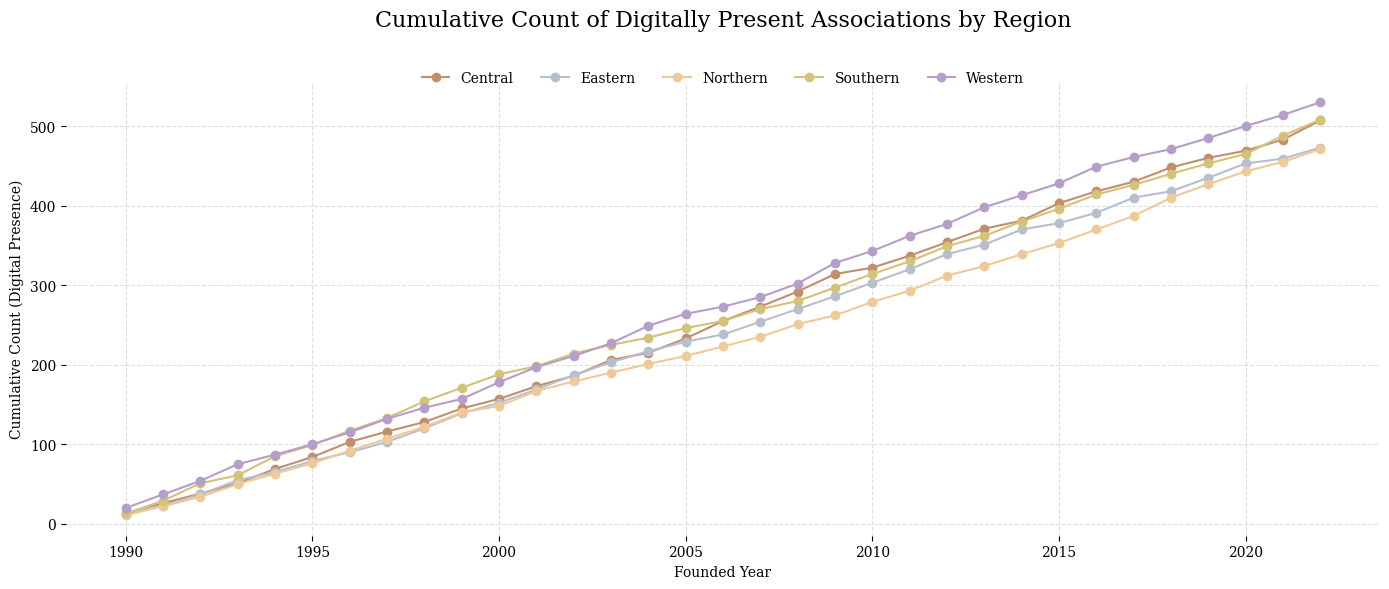

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تنقية البيانات
df = df.dropna(subset=['Region', 'Founded Year', 'Digital Presence'])
df['Digital Presence'] = df['Digital Presence'].str.strip().str.lower()

# إبقاء فقط المنظمات التي لديها حضور رقمي
df_digital = df[df['Digital Presence'] == 'yes']

# حساب عدد المنظمات لكل منطقة وسنة
grouped = df_digital.groupby(['Region', 'Founded Year']).size().reset_index(name='Count')

# حساب التراكم
grouped['Cumulative Count'] = grouped.groupby('Region')['Count'].cumsum()

# ألوان المناطق المعتمدة
region_colors = {
    'Central': '#c18f6c',
    'Eastern': '#b7bfce',
    'Northern': '#efc999',
    'Southern': '#d3c277',
    'Western': '#b59ec9'
}

# الرسم
plt.figure(figsize=(14, 6))  # توسيع الشكل لضمان الليجند بسطر واحد
for region, color in region_colors.items():
    data = grouped[grouped['Region'] == region]
    plt.plot(data['Founded Year'], data['Cumulative Count'],
             marker='o', label=region, color=color)

# العناوين والمحاور
plt.title('Cumulative Count of Digitally Present Associations by Region', fontsize=16, pad=40)
plt.xlabel('Founded Year')
plt.ylabel('Cumulative Count (Digital Presence)')
plt.grid(True, linestyle='--', alpha=0.4)

# إزالة الإطار الخارجي
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ليجند أنيق بدون عنوان، وعلى سطر واحد
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False)

plt.tight_layout()
plt.show()


<ipython-input-40-b32a1ebddde9>:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



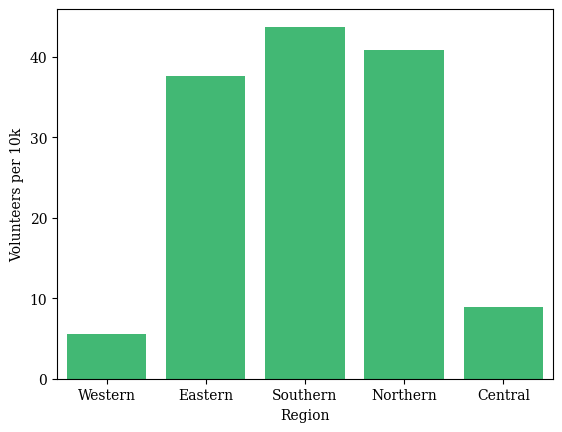

In [ ]:
import pandas as pd

# تنقية البيانات
df['Founded Year'] = pd.to_numeric(df['Founded Year'], errors='coerce')
df = df.dropna(subset=['Region', 'Founded Year', 'Volunteers', 'Number of Beneficiaries'])
df_2022 = df[df['Founded Year'] == 2022]

# مجموع المتطوعين والمستفيدين حسب المنطقة
summary_2022 = df_2022.groupby('Region')[['Volunteers', 'Number of Beneficiaries']].sum().reset_index()

# عدد السكان لكل منطقة
population = {
    'Southern': 1014543,
    'Northern': 1334659,
    'Western': 8800265,
    'Central': 8591748,
    'Eastern': 1386000
}

# حساب المعدلات لكل 100 ألف نسمة
summary_2022['Population'] = summary_2022['Region'].map(population).astype(float)
summary_2022['Volunteers per 10k'] = (summary_2022['Volunteers'] / summary_2022['Population']) * 10000
summary_2022['Beneficiaries per 10k'] = (summary_2022['Number of Beneficiaries'] / summary_2022['Population']) * 10000

summary_2022

fig3 = sns.barplot(data=summary_2022, x='Region', y='Volunteers per 10k', color='#2ECC71')

<ipython-input-57-1fe9fe3e80ab>:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



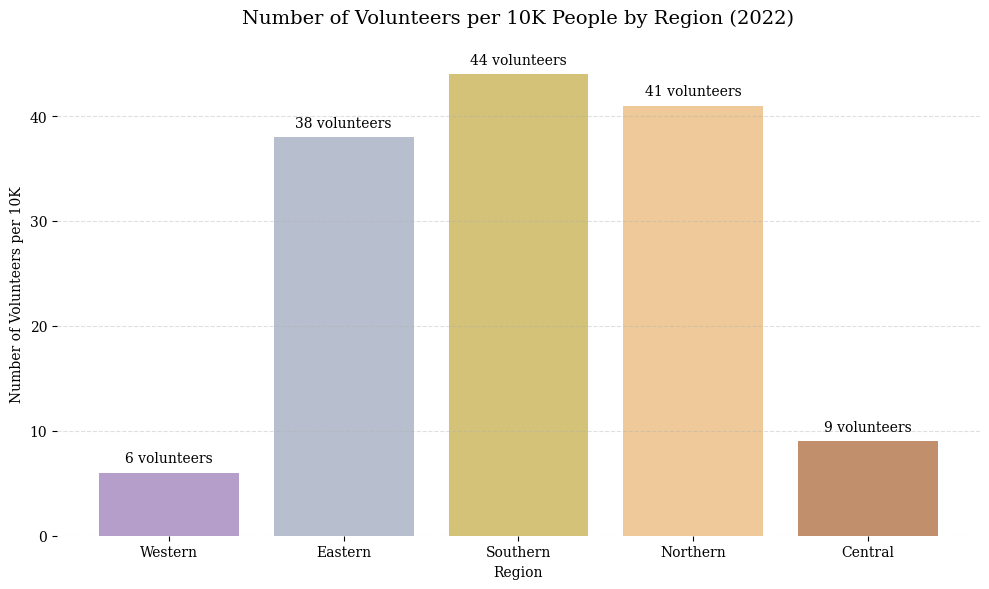

In [ ]:
# إعادة تحميل البيانات وتنفيذ الرسم بعد إعادة تشغيل البيئة
import pandas as pd
import matplotlib.pyplot as plt


# عدد السكان حسب المنطقة (2022)
region_population = {
    'Southern': 1014543,
    'Northern': 1334659,
    'Western': 8800265,
    'Central': 8591748,
    'Eastern': 1386000
}

# تصفية البيانات على سنة 2022
df['Founded Year'] = pd.to_numeric(df['Founded Year'], errors='coerce')
df = df.dropna(subset=['Region', 'Founded Year', 'Volunteers'])
df_2022 = df[df['Founded Year'] == 2022]

# تجميع عدد المتطوعين حسب المنطقة
summary = df_2022.groupby('Region')['Volunteers'].sum().reset_index()
summary['Population'] = summary['Region'].map(region_population)
summary['Population'] = summary['Population'].astype(float)
summary['Volunteers per 10k'] = summary['Volunteers'] / summary['Population'] * 10000
summary['Volunteers per 10k'] = summary['Volunteers per 10k'].round(0).astype(int)
# ترتيب المناطق نفس المعتاد
region_order = ['Western', 'Eastern', 'Southern', 'Northern', 'Central']
summary['Region'] = pd.Categorical(summary['Region'], categories=region_order, ordered=True)
summary = summary.sort_values('Region')

# ألوان المناطق
region_colors = {
    'Central': '#c18f6c',
    'Eastern': '#b7bfce',
    'Northern': '#efc999',
    'Southern': '#d3c277',
    'Western': '#b59ec9'
}

# رسم عمودي للمتطوعين لكل 10 آلاف نسمة
plt.figure(figsize=(10, 6))
bars = plt.bar(summary['Region'], summary['Volunteers per 10k'],
               color=[region_colors[r] for r in summary['Region']])

# إضافة القيم على الأعمدة
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{int(height)} volunteers", ha='center', color='black', fontsize=10)

plt.title('Number of Volunteers per 10K People by Region (2022)', fontsize=14, pad=20)
plt.xlabel('Region')
plt.ylabel('Number of Volunteers per 10K')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# إزالة الإطار
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
summ

In [ ]:

import plotly.express as px

fig = px.violin(
    df,
    x='Digital Presence',
    y='Rating (out of 100)',  # استبدليها بالاسم الصحيح لعمود التقييم
    color='Digital Presence',
    box=True,
    title='Impact of Digital Presence on Organization Rating',
    color_discrete_map={'yes': '#2ECC71', 'no': '#D32F2F'}
)
fig.add_hline(y=91, line_dash="dash", line_color='#228B22')
fig.add_hline(y=90, line_dash="dash", line_color="#D32F2F")
fig.update_layout(
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        zeroline=False
    ),
    width=1000,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()


In [ ]:
import plotly.graph_objects as go

# تقسيم البيانات
yes_data = df[df['Digital Presence'].str.lower() == 'yes']['Rating (out of 100)']
no_data = df[df['Digital Presence'].str.lower() == 'no']['Rating (out of 100)']

fig = go.Figure()

# الفئة yes
fig.add_trace(go.Violin(
    y=yes_data,
    x=['yes'] * len(yes_data),
    name='yes',
    box_visible=True,
    meanline_visible=True,
    line_color='#2ECC71',
    fillcolor='rgba(46, 204, 113, 0.4)',
    opacity=0.6
))

# الفئة no
fig.add_trace(go.Violin(
    y=no_data,
    x=['no'] * len(no_data),
    name='no',
    box_visible=True,
    meanline_visible=True,
    line_color='#D32F2F',
    fillcolor='rgba(211, 47, 47, 0.4)',
    opacity=0.6
))

# تنسيق التصميم
fig.update_layout(
    title='Impact of Digital Presence on Organization Rating',
    yaxis_title='Rating (out of 100)',
    xaxis_title='Digital Presence',
    violingap=0.3,
    violinmode='overlay',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Verdana', size=14)
)

fig.show()


<Axes: xlabel='Digital Presence', ylabel='Rating (out of 100)'>

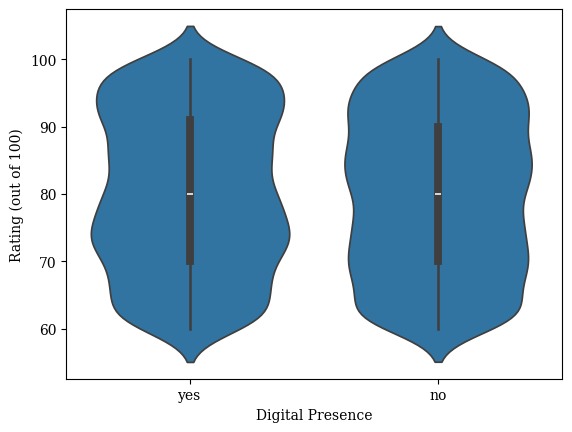

In [ ]:
import seaborn as sns
sns.violinplot(data=df, x='Digital Presence', y='Rating (out of 100)')

In [ ]:
import plotly.express as px

# بيانات الجمعيات اللي عندهم حضور رقمي
digital_df = df[df['Digital Presence'].str.strip().str.lower() == 'yes']

# عدد الجمعيات حسب المدينة
city_counts = digital_df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Count']

# إحداثيات المدن
coords = {
    'Riyadh': (24.7136, 46.6753),
    'Jeddah': (21.5433, 39.1728),
    'Makkah': (21.3891, 39.8579),
    'Medina': (24.5247, 39.5692),
    'Dammam': (26.4207, 50.0888),
    'Abha': (18.2164, 42.5052),
    'Tabuk': (28.3838, 36.5550),
    'Najran': (17.4917, 44.1322),
    'Hail': (27.5114, 41.7208),
    'Taif': (21.4373, 40.5127)
}

city_counts['lat'] = city_counts['City'].map(lambda c: coords[c][0])
city_counts['lon'] = city_counts['City'].map(lambda c: coords[c][1])

# ربط المدن بمناطقها
region_map = {
    'Riyadh': 'Central',
    'Jeddah': 'Western',
    'Makkah': 'Western',
    'Medina': 'Western',
    'Dammam': 'Eastern',
    'Abha': 'Southern',
    'Najran': 'Southern',
    'Tabuk': 'Northern',
    'Hail': 'Northern',
    'Taif': 'Western'
}
city_counts['Region'] = city_counts['City'].map(region_map)

# النص داخل الفقاعة
city_counts['Label'] = city_counts.apply(lambda row: f"{row['City']}: {row['Count']}", axis=1)

# رسم الخريطة
fig = px.scatter_geo(
    city_counts,
    lat='lat',
    lon='lon',
    text='Label',
    size=city_counts['Count'] * 100000000,
    color='Region',
    hover_name='City',
    hover_data={'Count': True, 'lat': False, 'lon': False},
    projection='mercator',
    scope='asia',
    title='Digital Presence Enabled - By City',
    size_max=60,
    opacity=0.8
)

fig.update_geos(
    visible=False,
    showland=True,
    landcolor='whitesmoke',
    showcountries=True,
    countrycolor='lightgray',
    fitbounds="locations"
)

fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Verdana', size=14, color='black')
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# تصفية الجمعيات ذات الحضور الرقمي
digital_df = df[df['Digital Presence'].str.strip().str.lower() == 'yes']

# حساب عدد الجمعيات حسب المدينة
city_counts = digital_df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Count']

# إحداثيات المدن
coords = {
    'Riyadh': (24.7136, 46.6753),
    'Jeddah': (21.5433, 39.1728),
    'Makkah': (21.3891, 39.8579),
    'Medina': (24.5247, 39.5692),
    'Dammam': (26.4207, 50.0888),
    'Abha': (18.2164, 42.5052),
    'Tabuk': (28.3838, 36.5550),
    'Najran': (17.4917, 44.1322),
    'Hail': (27.5114, 41.7208),
    'Taif': (21.4373, 40.5127)
}
city_counts['lat'] = city_counts['City'].map(lambda c: coords[c][0])
city_counts['lon'] = city_counts['City'].map(lambda c: coords[c][1])

# ربط المدن بالمناطق
region_map = {
    'Riyadh': 'Central',
    'Jeddah': 'Western',
    'Makkah': 'Western',
    'Medina': 'Western',
    'Dammam': 'Eastern',
    'Abha': 'Southern',
    'Najran': 'Southern',
    'Tabuk': 'Northern',
    'Hail': 'Northern',
    'Taif': 'Western'
}
city_counts['Region'] = city_counts['City'].map(region_map)

# ألوان مخصصة للمناطق
region_colors = {
    'Central': '#FFB347',
    'Western': '#FF6961',
    'Southern': '#779ECB',
    'Eastern': '#C39BD3',
    'Northern': '#77DD77'
}

# رسم الخريطة بالرمز diamond بدل pin
fig = go.Figure()

for _, row in city_counts.iterrows():
    fig.add_trace(go.Scattergeo(
        lon=[row['lon']],
        lat=[row['lat']],
        text=f"{row['City']}: {row['Count']}",
        marker=dict(
            symbol='star',  # ← بديل مرئي للدبوس
            size=12 + row['Count'] * 0.05,
            color=region_colors[row['Region']],
            line=dict(width=1, color='black')
        ),
        name=row['City']
    ))

fig.update_layout(
    geo=dict(
        projection_type='mercator',
        showland=True,
        landcolor='whitesmoke',
        showcountries=True,
        countrycolor='lightgray',
        fitbounds="locations"
    ),
    title='Digital Presence Enabled - By City (Diamond Marker)',
    margin=dict(r=0, t=40, l=0, b=0),
    font=dict(family='Verdana', size=14, color='black')
)

fig.show()


In [ ]:
import geopandas as gpd
import requests

url = "https://raw.githubusercontent.com/homaily/Saudi-Arabia-Regions-Cities-and-Districts/master/json/regions.json"

# حفظ الملف مؤقتًا
with open("regions.json", "w", encoding="utf-8") as f:
    f.write(requests.get(url).text)

# قراءة البيانات الجغرافية
gdf = gpd.read_file("regions.json")
gdf['name_en'].unique()  # أو استبدلي name_en بالعمود المناسب


DataSourceError: 'regions.json' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

In [ ]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/houssemmohamed/GIS_Datasets/main/geojson/saudi-arabia-regions.geojson"
gdf = gpd.read_file(url)

gdf.plot()  # مجرد تأكيد إن الخريطة تشتغل
gdf.columns  # عشان نعرف اسم العمود اللي فيه اسم المنطقة


HTTPError: HTTP Error 404: Not Found

In [ ]:
url = "https://raw.githubusercontent.com/houssemmohamed/GIS_Datasets/main/geojson/saudi-arabia-regions.geojson"

import geopandas as gpd
import json

with open("regions.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# استعراض أول مفتاح
list(data.keys())

gdf.plot()


JSONDecodeError: Expecting ',' delimiter: line 98910 column 3 (char 1626285)